In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import cv2
import tensorflow as tf
from tensorflow import keras
from keras import layers, models
from keras.utils import to_categorical
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [2]:
DATASET_PATH = "dataset" 
ALERT_FOLDER = "Active Subjects" 
DROWSY_FOLDER = "Fatigue Subjects"
IMG_SIZE = 64 
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 0.001
TEST_SIZE = 0.2
RANDOM_STATE = 42

In [3]:
def check_gpu_availability():
    print("CHECKING HARDWARE CONFIGURATION")
    
    gpus = tf.config.list_physical_devices('GPU')
    
    if gpus:
        try:
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
            
            print(f"GPU DETECTED: {len(gpus)} GPU(s) available")
            for i, gpu in enumerate(gpus):
                print(f"   GPU {i}: {gpu.name}")
            
            gpu_details = tf.config.experimental.get_device_details(gpus[0])
            print(f"   Device Name: {gpu_details.get('device_name', 'Unknown')}")
            
            print(f"\nTraining will use GPU acceleration")
            return True
            
        except RuntimeError as e:
            print(f"GPU detected but error during configuration: {e}")
            print("Falling back to CPU")
            return False
    else:
        print("NO GPU DETECTED")
        print("Training will use CPU ")
        
        cpu_info = tf.config.list_physical_devices('CPU')
        if cpu_info:
            print(f"   Available CPUs: {len(cpu_info)}")
        
        return False
    

In [4]:
def load_dataset(dataset_path, img_size):
    images = []
    labels = []
    
    # Define class names and corresponding label values
    classes = {ALERT_FOLDER: 0, DROWSY_FOLDER: 1}
    
    print("Loading dataset...")
    
    for class_name, label in classes.items():
        class_path = os.path.join(dataset_path, class_name)
        
        # Check if directory exists
        if not os.path.exists(class_path):
            print(f"Warning: Directory {class_path} does not exist!")
            continue
        
        # Load all images from the class directory
        image_files = os.listdir(class_path)
        print(f"Loading {len(image_files)} images from {class_name}/")
        
        for img_file in image_files:
            img_path = os.path.join(class_path, img_file)
            
            try:
                # Read image in grayscale (single channel)
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                
                if img is None:
                    continue
                
                # Resize image to fixed size
                img_resized = cv2.resize(img, (img_size, img_size))
                
                # Normalize pixel values to [0, 1]
                img_normalized = img_resized / 255.0
                
                images.append(img_normalized)
                labels.append(label)
                
            except Exception as e:
                print(f"Error loading {img_path}: {e}")
    
    # Convert lists to NumPy arrays
    images = np.array(images)
    labels = np.array(labels)
    
    images = images.reshape(-1, img_size, img_size, 1)
    
    print(f"\nDataset loaded successfully!")
    print(f"Total images: {len(images)}")
    print(f"Image shape: {images.shape}")
    print(f"Active/Alert images: {np.sum(labels == 0)}")
    print(f"Fatigue/Drowsy images: {np.sum(labels == 1)}")
    
    return images, labels


In [5]:
def build_cnn_model(input_shape, num_classes):
    model = models.Sequential([
        # First Convolutional Block
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape, padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Second Convolutional Block
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Third Convolutional Block
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),
        
        # Flatten and Dense Layers
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.4),
        
        # Output Layer
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

In [6]:
def train_model(model, X_train, y_train, X_test, y_test, epochs, batch_size):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # Define callbacks
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
    
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
    
    # Train model
    print("\nTraining model...")
    history = model.fit(
        X_train, y_train,
        batch_size=batch_size,
        epochs=epochs,
        validation_data=(X_test, y_test),
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )
    
    return history



In [17]:
def evaluate_model(model, X_test, y_test):
    # Predict on test data
    y_pred_prob = model.predict(X_test)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = np.argmax(y_test, axis=1)
    
    # Calculate accuracy
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f"\nTest Accuracy: {test_accuracy * 100:.2f}%")
    print(f"Test Loss: {test_loss:.4f}")
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['Alert', 'Drowsy']))
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Alert', 'Drowsy'],
                yticklabels=['Alert', 'Drowsy'])
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    #plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

In [18]:
def plot_training_history_simple(history):
    fig, ax = plt.subplots(figsize=(7, 5))
    
    ax.plot(history.history['accuracy'], label='Train Accuracy')
    ax.plot(history.history['val_accuracy'], label='Validation Accuracy')
    
    ax.set_title('Model Accuracy')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True)
    
    plt.tight_layout()
    #plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)

In [9]:
gpu_available = check_gpu_availability()

CHECKING HARDWARE CONFIGURATION
GPU DETECTED: 1 GPU(s) available
   GPU 0: /physical_device:GPU:0
   Device Name: NVIDIA GeForce RTX 4050 Laptop GPU

Training will use GPU acceleration


In [10]:
if __name__ == "__main__":
    print("DRIVER DROWSINESS DETECTION - MODEL TRAINING")
    
    images, labels = load_dataset(DATASET_PATH, IMG_SIZE)
    
    labels_categorical = to_categorical(labels, num_classes=2)
    
    X_train, X_test, y_train, y_test = train_test_split(
        images, labels_categorical,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=labels
    )
    
    print(f"\nTraining set size: {len(X_train)}")
    print(f"Test set size: {len(X_test)}")
    
    input_shape = (IMG_SIZE, IMG_SIZE, 1)
    model = build_cnn_model(input_shape, num_classes=2)
    
    print("\nModel Architecture:")
    model.summary()
    
    if gpu_available:
        print(" TRAINING ON: GPU")
    else:
        print(" TRAINING ON: CPU")
    

DRIVER DROWSINESS DETECTION - MODEL TRAINING
Loading dataset...
Loading 19445 images from Active Subjects/
Loading 22348 images from Fatigue Subjects/

Dataset loaded successfully!
Total images: 41793
Image shape: (41793, 64, 64, 1)
Active/Alert images: 19445
Fatigue/Drowsy images: 22348

Training set size: 33434
Test set size: 8359

Model Architecture:
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 64, 64, 32)        320       
                                                                 
 batch_normalization (BatchN  (None, 64, 64, 32)       128       
 ormalization)                                                   
                                                                 
 max_pooling2d (MaxPooling2D  (None, 32, 32, 32)       0         
 )                                                               
                              

In [11]:
history = train_model(model, X_train, y_train, X_test, y_test, EPOCHS, BATCH_SIZE)


Training model...
Epoch 1/10
1045/1045 [==============================] - 18s 10ms/step - loss: 0.1130 - accuracy: 0.9586 - val_loss: 0.0382 - val_accuracy: 0.9877 - lr: 0.0010
Epoch 2/10
1045/1045 [==============================] - 10s 9ms/step - loss: 0.0236 - accuracy: 0.9923 - val_loss: 0.0032 - val_accuracy: 0.9990 - lr: 0.0010
Epoch 3/10
1045/1045 [==============================] - 10s 10ms/step - loss: 0.0148 - accuracy: 0.9951 - val_loss: 0.0025 - val_accuracy: 0.9993 - lr: 0.0010
Epoch 4/10
1045/1045 [==============================] - 10s 9ms/step - loss: 0.0111 - accuracy: 0.9970 - val_loss: 0.0030 - val_accuracy: 0.9990 - lr: 0.0010
Epoch 5/10
1045/1045 [==============================] - 10s 9ms/step - loss: 0.0112 - accuracy: 0.9966 - val_loss: 0.0029 - val_accuracy: 0.9992 - lr: 0.0010
Epoch 6/10
1040/1045 [============================>.] - ETA: 0s - loss: 0.0090 - accuracy: 0.9974
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1045/1045 [====

262/262 [==============================] - 1s 2ms/step

Test Accuracy: 99.98%
Test Loss: 0.0006

Classification Report:
              precision    recall  f1-score   support

       Alert       1.00      1.00      1.00      3889
      Drowsy       1.00      1.00      1.00      4470

    accuracy                           1.00      8359
   macro avg       1.00      1.00      1.00      8359
weighted avg       1.00      1.00      1.00      8359



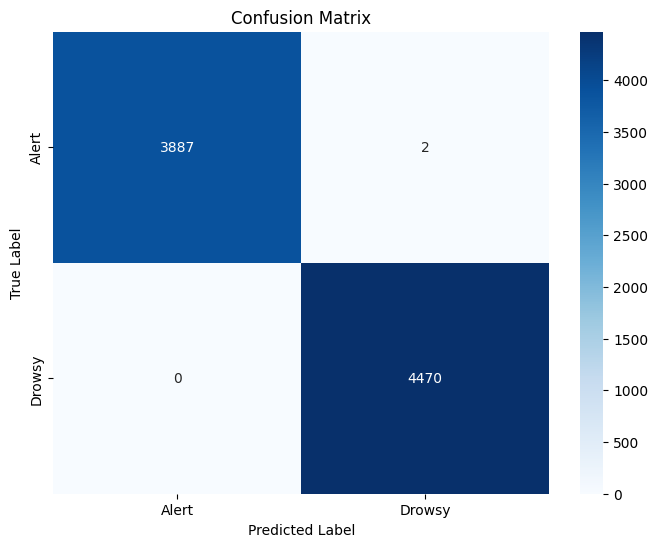

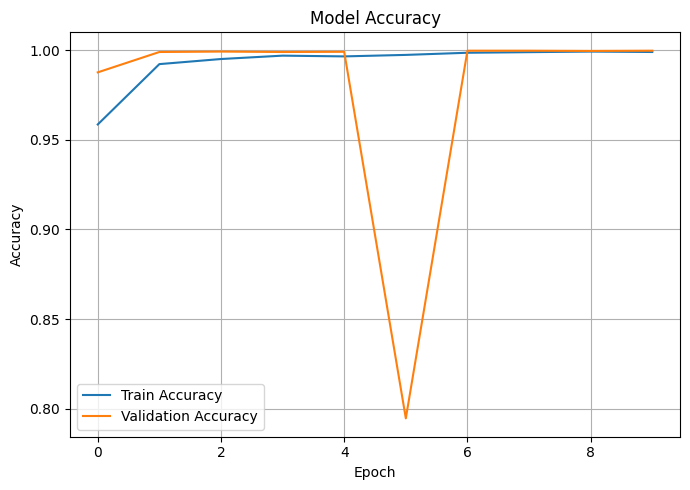

In [16]:
evaluate_model(model, X_test, y_test)
    
plot_training_history_simple(history)

In [14]:
model.save('model.h5')
print("\nModel saved successfully as 'model.h5'")
print("TRAINING COMPLETE!")


Model saved successfully as 'model.h5'
TRAINING COMPLETE!


In [9]:
import os
import glob
from PIL import Image, ImageDraw, ImageFont

# Configuration (must match Step 1)
IMAGE_PREFIX = "random_sample_"
GRID_COLS = 4
GRID_ROWS = 2
IMG_SIZE = 64
TEXT_HEIGHT = 20 
PADDING = 10
FINAL_IMG_WIDTH = GRID_COLS * (IMG_SIZE + 2 * PADDING)
FINAL_IMG_HEIGHT = GRID_ROWS * (IMG_SIZE + TEXT_HEIGHT + 2 * PADDING)

def create_combined_grid():
    """Finds individual sample images, loads them, and combines them into a single grid image."""
    
    # 1. Search for files
    image_files = glob.glob(f"{IMAGE_PREFIX}*.jpg")
    image_files.extend(glob.glob(f"{IMAGE_PREFIX}*.png"))
    
    if not image_files:
        print(f"Error: No images found with prefix '{IMAGE_PREFIX}' and extension .jpg or .png. Please run Step 1 first.")
        return
        
    image_files.sort()
    
    print(f"Found {len(image_files)} sample images. Combining into a grid...")

    # 2. Create the blank canvas
    combined_img = Image.new('RGB', (FINAL_IMG_WIDTH, FINAL_IMG_HEIGHT), color='white')
    draw = ImageDraw.Draw(combined_img)

    try:
        font = ImageFont.truetype("arial.ttf", 14)
    except IOError:
        font = ImageFont.load_default()
    
    # 3. Arrange and Combine
    for i, file_path in enumerate(image_files):
        if i >= GRID_COLS * GRID_ROWS:
            break
            
        try:
            # Load and convert to RGB for the final combined image
            img = Image.open(file_path).convert("L").resize((IMG_SIZE, IMG_SIZE))
            img_rgb = img.convert("RGB")
        except Exception as e:
            print(f"Error loading {file_path}: {e}. Skipping.")
            continue
            
        # Extract class label from filename (e.g., random_sample_#_CLASS_...)
        try:
            # Class name is the 4th element (index 3) when splitting by '_'
            class_name = file_path.split('_')[3].split('.')[0]
        except IndexError:
            class_name = "Unknown"
        
        # Calculate grid position
        row = i // GRID_COLS
        col = i % GRID_COLS
        
        # Coordinates for image and text
        x_start = col * (IMG_SIZE + 2 * PADDING) + PADDING
        y_start = row * (IMG_SIZE + TEXT_HEIGHT + 2 * PADDING) + PADDING + TEXT_HEIGHT
        text_y = row * (IMG_SIZE + TEXT_HEIGHT + 2 * PADDING) + PADDING

        # Paste image and draw label
        combined_img.paste(img_rgb, (x_start, y_start))
        draw.text((x_start, text_y), f"Class: {class_name}", fill='black', font=font)

    # 4. Save the final image
    final_filename = "combined_drowsiness_samples_grid.png"
    combined_img.save(final_filename)
    print(f"\nSuccessfully created and saved the combined image grid: '{final_filename}'")

# Execute the function
create_combined_grid()

Found 29 sample images. Combining into a grid...

Successfully created and saved the combined image grid: 'combined_drowsiness_samples_grid.png'
